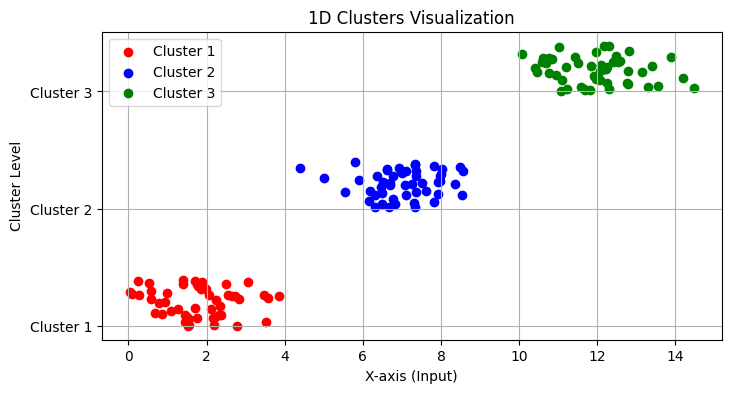

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Random seed
np.random.seed(42)

# Generate 1D clusters (single feature)
cluster_1 = np.random.randn(50) + 2   # Cluster 1 around 2
cluster_2 = np.random.randn(50) + 7   # Cluster 2 around 7
cluster_3 = np.random.randn(50) + 12  # Cluster 3 around 12

# Combine data
X = np.hstack([cluster_1, cluster_2, cluster_3])
Y = [1]*50 + [2]*50 + [3]*50  # Cluster labels

# Create DataFrame
df = pd.DataFrame({'X': X, 'Cluster': Y})

# Plot clusters with vertical randomness for better visualization
plt.figure(figsize=(8,4))
colors = {1:'red', 2:'blue', 3:'green'}
y_offsets = {1:0.5, 2:1.5, 3:2.5}  # different y-level for each cluster

for cluster in df['Cluster'].unique():
    subset = df[df['Cluster']==cluster]
    # Add small random vertical jitter around the cluster y-level
    y_jitter = y_offsets[cluster] + np.random.rand(len(subset))*0.4
    plt.scatter(subset['X'], y_jitter, c=colors[cluster], label=f'Cluster {cluster}')

plt.title('1D Clusters Visualization')
plt.xlabel('X-axis (Input)')
plt.ylabel('Cluster Level')
plt.yticks([0.5, 1.5, 2.5], ['Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.legend()
plt.grid(True)
plt.show()


# ELBOW METHOD

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [ ]:
wcss = []
for i in range(1,20):
  algo = KMeans(n_clusters=i)
  algo.fit_predict(df)
  wcss.append(algo.inertia_)

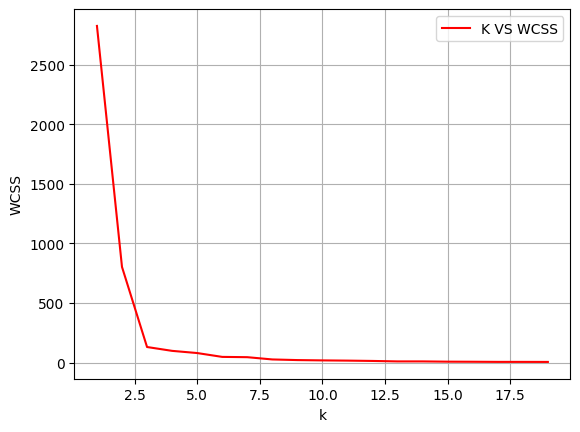

In [ ]:
k  = range(1,20)
plt.plot(k , wcss,color="red" ,label="K VS WCSS")
plt.legend()
plt.xlabel("k")
plt.ylabel("WCSS")
plt.grid()
plt.show()



In [56]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

k = range(1, 20)
  # your WCSS list
kl = KneeLocator(k, wcss, curve="convex", direction="decreasing")
elbow = kl.elbow
print("Optimal k:", elbow)


Optimal k: 3


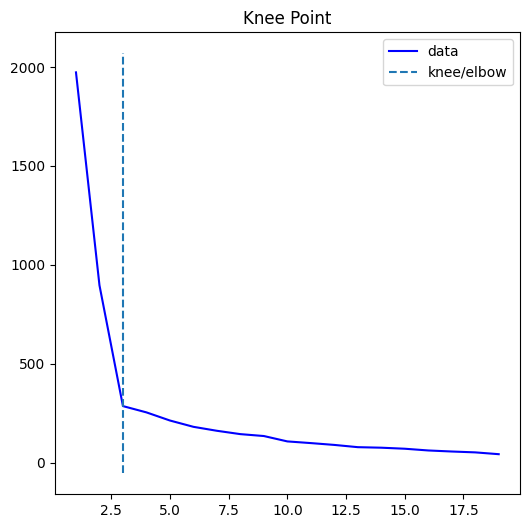

In [ ]:
kl.plot_knee()

In [ ]:
k = 3

cls = KMeans(n_clusters=k)
y_means =cls.fit_predict(df)

In [ ]:
y_means

#Value at that index → tells you the cluster number that row belongs to
#example: y_means  = [1 , 2 ,0 ,1 ,0]
# it means: row with index 0: belongs to cluster 1
# row with index : 1 :  belongs to cluster 2
# row with index : 2 :  belongs to cluster 0
# row with index : 3 :  belongs to cluster 1
# row with index : 4 :  belongs to cluster 0


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
x = df[::].values
x[y_means==0] # rows belongs to clustrer 0
#This uses boolean indexing to select all rows from x that belong to cluster 0.

array([[10.58462926,  3.        ],
       [11.57935468,  3.        ],
       [11.65728548,  3.        ],
       [11.19772273,  3.        ],
       [11.83871429,  3.        ],
       [12.40405086,  3.        ],
       [13.8861859 ,  3.        ],
       [12.17457781,  3.        ],
       [12.25755039,  3.        ],
       [11.92555408,  3.        ],
       [10.08122878,  3.        ],
       [11.97348612,  3.        ],
       [12.06023021,  3.        ],
       [14.46324211,  3.        ],
       [11.80763904,  3.        ],
       [12.30154734,  3.        ],
       [11.96528823,  3.        ],
       [10.83132196,  3.        ],
       [13.14282281,  3.        ],
       [12.75193303,  3.        ],
       [12.79103195,  3.        ],
       [11.09061255,  3.        ],
       [13.40279431,  3.        ],
       [10.59814894,  3.        ],
       [12.58685709,  3.        ],
       [14.19045563,  3.        ],
       [11.00946367,  3.        ],
       [11.43370227,  3.        ],
       [12.09965137,

In [ ]:
x[y_means ==0,1]
# extract col 1 of every row where y_means == 0

array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.])

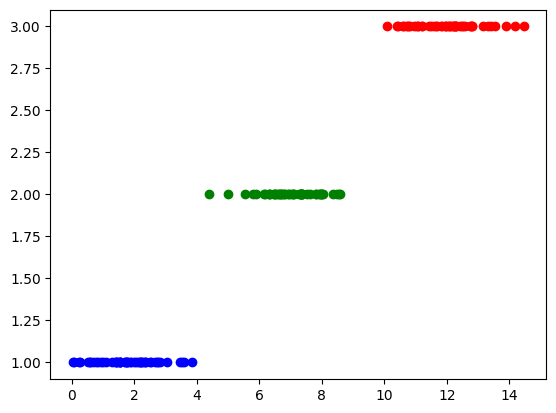

In [ ]:
plt.scatter(x[y_means==0 , 0] ,x[y_means==0 , 1] ,color ="red")
# x[y_means==0, 0] → selects all rows in cluster 0 and takes column 0 (usually x-axis).
# x[y_means==0, 1] → selects all rows in cluster 0 and takes column 1 (y-axis).
# color="red" → plots these points in red.
plt.scatter(x[y_means==1 , 0] ,x[y_means==1 , 1] ,color ="blue")
plt.scatter(x[y_means==2 , 0] ,x[y_means==2 , 1] ,color ="green")

# HIGH DIM DATA

In [53]:
from sklearn.datasets import make_blobs
import pandas as pd

# Parameters
n_samples = 300    # number of data points
n_features = 5     # dimensions (high-dimensional)
n_clusters = 4     # number of clusters

# Generate the data
X, y_true = make_blobs(n_samples=n_samples,
                       n_features=n_features,
                       centers=n_clusters,
                       cluster_std=1.0,
                       random_state=42)

# Convert to a DataFrame for convenience
df = pd.DataFrame(X, columns=[f'Feature_{i+1}' for i in range(n_features)])



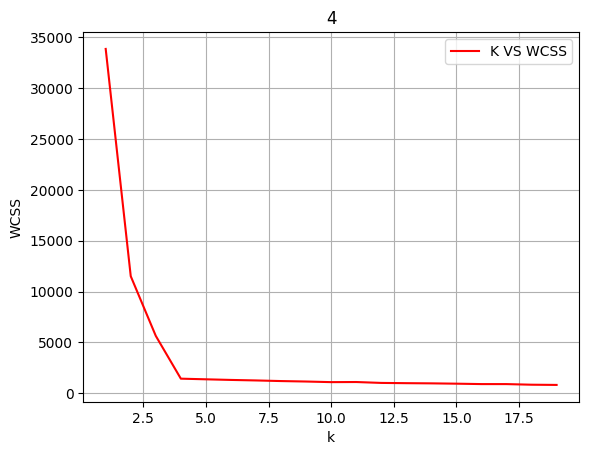

In [61]:
from kneed import KneeLocator
wcs = []
for i in range(1,20):
  kmean = KMeans(n_clusters= i)
  kmean.fit_predict(df)
  wcs.append(kmean.inertia_)
K  = range(1,20)

k = range(1, 20)
  # your WCSS list
kl = KneeLocator(k, wcs, curve="convex", direction="decreasing")
elbow = kl.elbow

plt.plot(k , wcs,color="red" ,label="K VS WCSS")
plt.title(f"{str(elbow)}")
plt.legend()
plt.xlabel("k")
plt.ylabel("WCSS")
plt.grid()
plt.show()



In [66]:
from kneed import KneeLocator
knee=KneeLocator(k , wcs , direction="decreasing" ,curve ="convex")
knee.elbow

np.int64(4)

In [110]:
alg = KMeans(n_clusters=4)
x= alg.fit_predict(df)
clusters = np.unique(x)
a =df.iloc[x==0,:3]
a["y"]=0

In [109]:
b= df.iloc[x==1 ,:3]
b["y"]=1

In [108]:
c= df.iloc[x==2 ,:3]
c["y"]=2

In [107]:
d= df.iloc[x==3 ,:3]
d["y"]=3


In [111]:
cluster_df = pd.concat([a,b,c,d] ,  axis =0)

In [87]:
import plotly.express as px

In [113]:
fig = px.scatter_3d(cluster_df, x='Feature_1', y='Feature_2', z='Feature_3', color='y',
                    title='3D Cluster Plot')
fig.show()